# T12C CNN Woodtype Probability Experiments

CNN woodtype probability を使った追加実験 1-4。既存の `train_df` / `test_df` が notebook 上にあればそれを使い、無ければ `data/train.csv`, `data/test.csv` と保存済み probability ファイルから自動復元します。すべての図と結果 CSV は `../outputs/cnn_woodtype_experiments/` に保存します。

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning)


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found. Run this notebook inside the repository.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import DataConfig, VIEW_NAMES
from src.data.load_data import detect_spectral_columns
from src.data.preprocessing import savitzky_golay_derivative, snv
from src.features.handcrafted_features import band_means, spectral_slopes
from src.features.phase_features import derivative_energy
from src.utils.plotting import configure_matplotlib_japanese

sns.set_theme(style="whitegrid")
configure_matplotlib_japanese()

config = DataConfig()
SPECIES_COL = "樹種"
TARGET_COL = "含水率"
SAMPLE_COL = "sample number"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "cnn_woodtype_experiments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
N_SPLITS = 5

print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUTPUT_DIR =", OUTPUT_DIR)

PROJECT_ROOT = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D
OUTPUT_DIR = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments


## Common Utilities

In [2]:
SOFTWOOD_CANDIDATES = ["softwood_prob", "prob_softwood", "p_softwood", "woodtype_softwood_prob", "prob_woodtype_softwood"]
HARDWOOD_CANDIDATES = ["hardwood_prob", "prob_hardwood", "p_hardwood", "woodtype_hardwood_prob", "prob_woodtype_hardwood"]
META_COLS = {SAMPLE_COL, "species number", SPECIES_COL, TARGET_COL, "true_woodtype", "pred_woodtype", "split"}
PROB_PATTERNS = ("prob", "softwood", "hardwood", "entropy", "uncertainty", "maxprob", "woodtype")


def safe_rmse(y_true, y_pred) -> float:
    from sklearn.metrics import mean_squared_error

    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def savefig(name: str) -> Path:
    path = OUTPUT_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=100)
    print("saved:", path)
    return path


def read_csv_auto(path: Path) -> pd.DataFrame:
    if path.parent.name == "data":
        header = pd.read_csv(path, encoding="cp932", nrows=0, engine="python").columns
        spectral_dtypes = {}
        for col in header:
            try:
                float(col)
                spectral_dtypes[col] = "float32"
            except ValueError:
                continue
        return pd.read_csv(path, encoding="cp932", dtype=spectral_dtypes)
    last_error: Exception | None = None
    for enc in ["cp932", "utf-8-sig", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except (UnicodeDecodeError, pd.errors.ParserError) as exc:
            last_error = exc
            continue
    if last_error is not None:
        raise last_error
    return pd.read_csv(path, low_memory=False)


def read_metadata_csv(path: Path, include_target: bool) -> pd.DataFrame:
    header = pd.read_csv(path, encoding="cp932", nrows=0, engine="python").columns
    cols = [c for c in [SAMPLE_COL, "species number", SPECIES_COL, TARGET_COL] if c in header and (include_target or c != TARGET_COL)]
    return pd.read_csv(path, encoding="cp932", usecols=cols)


def pick_col(df: pd.DataFrame, candidates: list[str], fuzzy_keywords: list[str] | None = None) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    if fuzzy_keywords:
        for col in df.columns:
            low = str(col).lower()
            if all(k.lower() in low for k in fuzzy_keywords):
                return col
    return None


def find_probability_files(split: str) -> list[Path]:
    roots = [PROJECT_ROOT / "outputs", PROJECT_ROOT / "data", PROJECT_ROOT]
    patterns = [
        f"**/*{split}*woodtype*prob*.csv",
        f"**/*{split}*wood_type*prob*.csv",
        f"**/*woodtype*{split}*prob*.csv",
        f"**/*wood_type*{split}*prob*.csv",
    ]
    scored = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            for p in root.glob(pattern):
                score = 0
                text = str(p).lower()
                if "t12_cnn_soft_routing" in text:
                    score += 10
                if "oof" in text and split == "train":
                    score += 5
                if "test" in text and split == "test":
                    score += 5
                scored.append((score, -len(str(p)), p))
    return [p for _, _, p in sorted(set(scored), reverse=True)]


def load_probability_frame(split: str) -> pd.DataFrame | None:
    explicit = {
        "train": PROJECT_ROOT / "outputs" / "T12_cnn_soft_routing" / "oof" / "train_woodtype_oof_probs.csv",
        "test": PROJECT_ROOT / "outputs" / "T12_cnn_soft_routing" / "test" / "test_woodtype_probs.csv",
    }[split]
    candidates = [explicit, *find_probability_files(split)]
    seen = set()
    for path in candidates:
        if path in seen or not path.exists():
            continue
        seen.add(path)
        try:
            df = read_csv_auto(path)
        except Exception:
            continue
        soft_col = pick_col(df, SOFTWOOD_CANDIDATES, ["softwood"])
        hard_col = pick_col(df, HARDWOOD_CANDIDATES, ["hardwood"])
        if soft_col is not None or hard_col is not None:
            print(f"loaded {split} probability:", path)
            return df
    return None


def load_raw_train_test_if_needed() -> tuple[pd.DataFrame, pd.DataFrame]:
    g = globals()
    if "train_df" in g and "test_df" in g:
        print("using existing train_df / test_df")
        return g["train_df"].copy(), g["test_df"].copy()
    train_path = PROJECT_ROOT / "data" / config.train_csv
    test_path = PROJECT_ROOT / "data" / config.test_csv
    print("loading raw csv:", train_path, test_path)
    return read_metadata_csv(train_path, include_target=True), read_metadata_csv(test_path, include_target=False)


def align_and_merge_probs(base_df: pd.DataFrame, prob_df: pd.DataFrame | None, split: str) -> pd.DataFrame:
    out = base_df.copy()
    if prob_df is None:
        print(f"warning: {split} probability dataframe was not found")
        return out
    prob = prob_df.copy()
    merge_key = SAMPLE_COL if SAMPLE_COL in out.columns and SAMPLE_COL in prob.columns else None
    prob_cols = [c for c in prob.columns if c not in out.columns or c == merge_key]
    if merge_key is not None:
        out = out.merge(prob[prob_cols], on=merge_key, how="left")
    elif len(prob) == len(out):
        out = pd.concat([out.reset_index(drop=True), prob[[c for c in prob.columns if c not in out.columns]].reset_index(drop=True)], axis=1)
    else:
        raise ValueError(f"Cannot align {split} probabilities: no sample key and row counts differ")
    return out


def detect_prob_columns(df: pd.DataFrame) -> tuple[str, str]:
    soft_col = pick_col(df, SOFTWOOD_CANDIDATES, ["softwood"])
    hard_col = pick_col(df, HARDWOOD_CANDIDATES, ["hardwood"])
    if soft_col is None and hard_col is None:
        raise ValueError(f"No woodtype probability columns found. columns={list(df.columns)}")
    if soft_col is None:
        soft_col = "softwood_prob"
        df[soft_col] = 1.0 - pd.to_numeric(df[hard_col], errors="coerce")
    if hard_col is None:
        hard_col = "hardwood_prob"
        df[hard_col] = 1.0 - pd.to_numeric(df[soft_col], errors="coerce")
    return soft_col, hard_col


def add_probability_features(df: pd.DataFrame, soft_col: str, hard_col: str) -> pd.DataFrame:
    out = df.copy()
    p_soft = pd.to_numeric(out[soft_col], errors="coerce").clip(1e-8, 1.0)
    p_hard = pd.to_numeric(out[hard_col], errors="coerce").clip(1e-8, 1.0)
    total = (p_soft + p_hard).replace(0, np.nan)
    out["softwood_prob"] = p_soft / total
    out["hardwood_prob"] = p_hard / total
    probs = out[["softwood_prob", "hardwood_prob"]].to_numpy(dtype=float)
    out["entropy_woodtype"] = -(probs * np.log(np.clip(probs, 1e-8, 1.0))).sum(axis=1)
    out["uncertainty_woodtype"] = 1.0 - np.nanmax(probs, axis=1)
    out["maxprob_woodtype"] = np.nanmax(probs, axis=1)
    return out


def numeric_feature_columns(df: pd.DataFrame, exclude_probability: bool = False, exclude_target: bool = True) -> list[str]:
    cols = []
    for col in df.select_dtypes(include=[np.number]).columns:
        low = str(col).lower()
        if col in META_COLS:
            continue
        if exclude_target and col == TARGET_COL:
            continue
        if exclude_probability and any(p in low for p in PROB_PATTERNS):
            continue
        cols.append(col)
    return cols


def clean_xy(X: pd.DataFrame, y: pd.Series | np.ndarray | None = None):
    Xc = X.replace([np.inf, -np.inf], np.nan).copy()
    if y is None:
        return Xc
    yc = pd.Series(y).replace([np.inf, -np.inf], np.nan)
    mask = yc.notna().to_numpy()
    return Xc.loc[mask].reset_index(drop=True), yc.loc[mask].to_numpy(dtype=float)


def make_group_kfold(groups: pd.Series, n_splits: int = N_SPLITS) -> GroupKFold:
    from sklearn.model_selection import GroupKFold

    n_groups = pd.Series(groups).nunique(dropna=True)
    return GroupKFold(n_splits=max(2, min(n_splits, int(n_groups))))


def species_rmse_table(frame: pd.DataFrame, pred_col: str, true_col: str = TARGET_COL) -> pd.DataFrame:
    rows = []
    for species, g in frame.groupby(SPECIES_COL, dropna=False):
        rows.append({"species": species, "n": len(g), "rmse": safe_rmse(g[true_col], g[pred_col])})
    return pd.DataFrame(rows).sort_values("rmse", ascending=False).reset_index(drop=True)


def moisture_bin_rmse_table(frame: pd.DataFrame, pred_col: str, true_col: str = TARGET_COL, bins: int | list[float] = 6) -> pd.DataFrame:
    work = frame[[true_col, pred_col]].dropna().copy()
    if isinstance(bins, int):
        work["mc_bin"] = pd.qcut(work[true_col], q=bins, duplicates="drop")
    else:
        work["mc_bin"] = pd.cut(work[true_col], bins=bins, include_lowest=True)
    rows = []
    for b, g in work.groupby("mc_bin", observed=True):
        rows.append({"mc_bin": str(b), "n": len(g), "rmse": safe_rmse(g[true_col], g[pred_col])})
    return pd.DataFrame(rows)


def plot_actual_pred(frame: pd.DataFrame, pred_col: str, title: str, filename: str) -> None:
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=frame, x=TARGET_COL, y=pred_col, hue=SPECIES_COL, s=28, alpha=0.75, legend=False)
    lo = float(np.nanmin([frame[TARGET_COL].min(), frame[pred_col].min()]))
    hi = float(np.nanmax([frame[TARGET_COL].max(), frame[pred_col].max()]))
    plt.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--")
    plt.title(title)
    plt.xlabel("actual moisture")
    plt.ylabel("predicted moisture")
    savefig(filename)
    plt.show()
    plt.close("all")


def plot_species_index_predictions(frame: pd.DataFrame, pred_cols: list[str], title: str, filename: str) -> None:
    plt.close("all")
    keep_cols = [SPECIES_COL, TARGET_COL, *pred_cols]
    if SAMPLE_COL in frame.columns:
        keep_cols.append(SAMPLE_COL)
    work = frame[keep_cols].sort_values([SPECIES_COL, SAMPLE_COL] if SAMPLE_COL in frame.columns else [SPECIES_COL]).copy()
    work["species_index"] = work.groupby(SPECIES_COL, dropna=False).cumcount()
    species_values = work[SPECIES_COL].dropna().astype(str).unique().tolist()
    ncols = 3 if len(species_values) > 6 else 2
    nrows = math.ceil(len(species_values) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 2.2 * nrows), sharey=True)
    axes = np.asarray(axes).reshape(-1)
    for ax, species in zip(axes, species_values):
        g = work[work[SPECIES_COL].astype(str) == species]
        ax.plot(g["species_index"], g[TARGET_COL], marker="o", ms=3, lw=1.3, label="actual", color="black")
        for pred_col in pred_cols:
            ax.plot(g["species_index"], g[pred_col], marker="o", ms=2.5, lw=1.1, label=pred_col)
        ax.set_title(f"{species}  n={len(g)}")
        ax.set_xlabel("index within species")
        ax.set_ylabel("moisture")
        ax.grid(True, alpha=0.25)
    for ax in axes[len(species_values):]:
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False)
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    savefig(filename)
    plt.show()
    plt.close("all")

In [3]:
train_base, test_base = load_raw_train_test_if_needed()
train_prob_frame = load_probability_frame("train")
test_prob_frame = load_probability_frame("test")

train_exp = align_and_merge_probs(train_base, train_prob_frame, "train")
test_exp = align_and_merge_probs(test_base, test_prob_frame, "test")

soft_col, hard_col = detect_prob_columns(train_exp)
train_exp = add_probability_features(train_exp, soft_col, hard_col)
soft_col_test, hard_col_test = detect_prob_columns(test_exp)
test_exp = add_probability_features(test_exp, soft_col_test, hard_col_test)

print("train_exp:", train_exp.shape)
print("test_exp:", test_exp.shape)
print("probability columns:", soft_col, hard_col)
display(train_exp[[SAMPLE_COL, SPECIES_COL, TARGET_COL, "softwood_prob", "hardwood_prob", "entropy_woodtype", "uncertainty_woodtype"]].head())
display(test_exp[[SAMPLE_COL, SPECIES_COL, "softwood_prob", "hardwood_prob", "entropy_woodtype", "uncertainty_woodtype"]].head())

loading raw csv: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\data\train.csv C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\data\test.csv
loaded train probability: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\oof\train_woodtype_oof_probs.csv
loaded test probability: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\test\test_woodtype_probs.csv
train_exp: (1322, 13)
test_exp: (550, 11)
probability columns: prob_woodtype_softwood prob_woodtype_hardwood


,sample number,樹種,含水率,softwood_prob,hardwood_prob,entropy_woodtype,uncertainty_woodtype
0,1,イチョウ,216.129032,0.819041,0.180959,0.472844,0.180959
1,2,イチョウ,210.752688,0.951631,0.048369,0.193683,0.048369
2,3,イチョウ,205.913979,0.854318,0.145682,0.415145,0.145682
3,4,イチョウ,201.075269,0.892007,0.107993,0.342299,0.107993
4,5,イチョウ,196.236559,0.916274,0.083726,0.287777,0.083726


,sample number,樹種,softwood_prob,hardwood_prob,entropy_woodtype,uncertainty_woodtype
0,95,クスノキ,0.511000,0.489000,0.692905,0.489000
1,96,クスノキ,0.447765,0.552235,0.687680,0.447765
2,97,クスノキ,0.400190,0.599810,0.673089,0.400190
3,98,クスノキ,0.415448,0.584552,0.678780,0.415448
4,99,クスノキ,0.459612,0.540388,0.689881,0.459612


## Experiment 1: softwood_prob vs Moisture

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp1_softwood_prob_vs_moisture_overlay_train.png


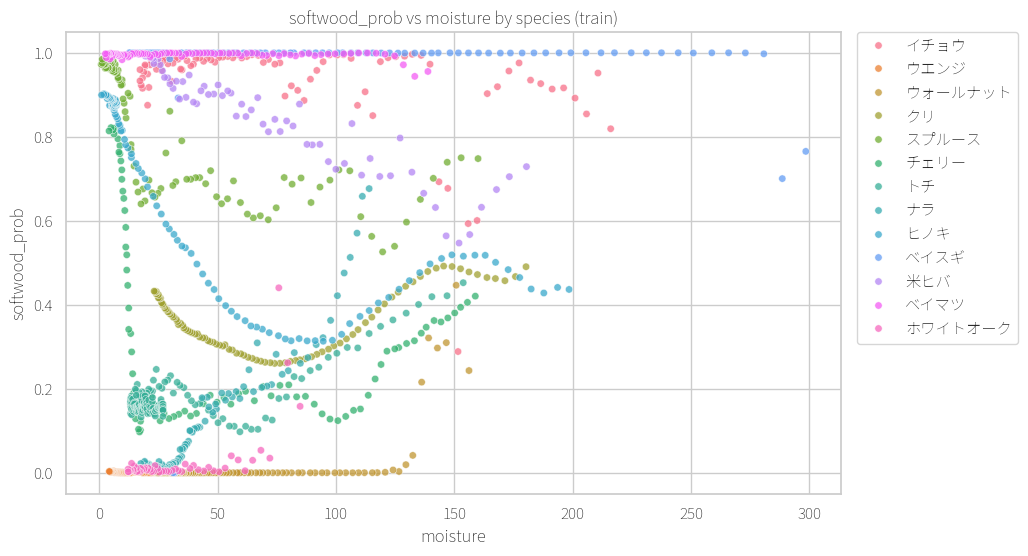

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp1_softwood_prob_vs_moisture_grid_train.png


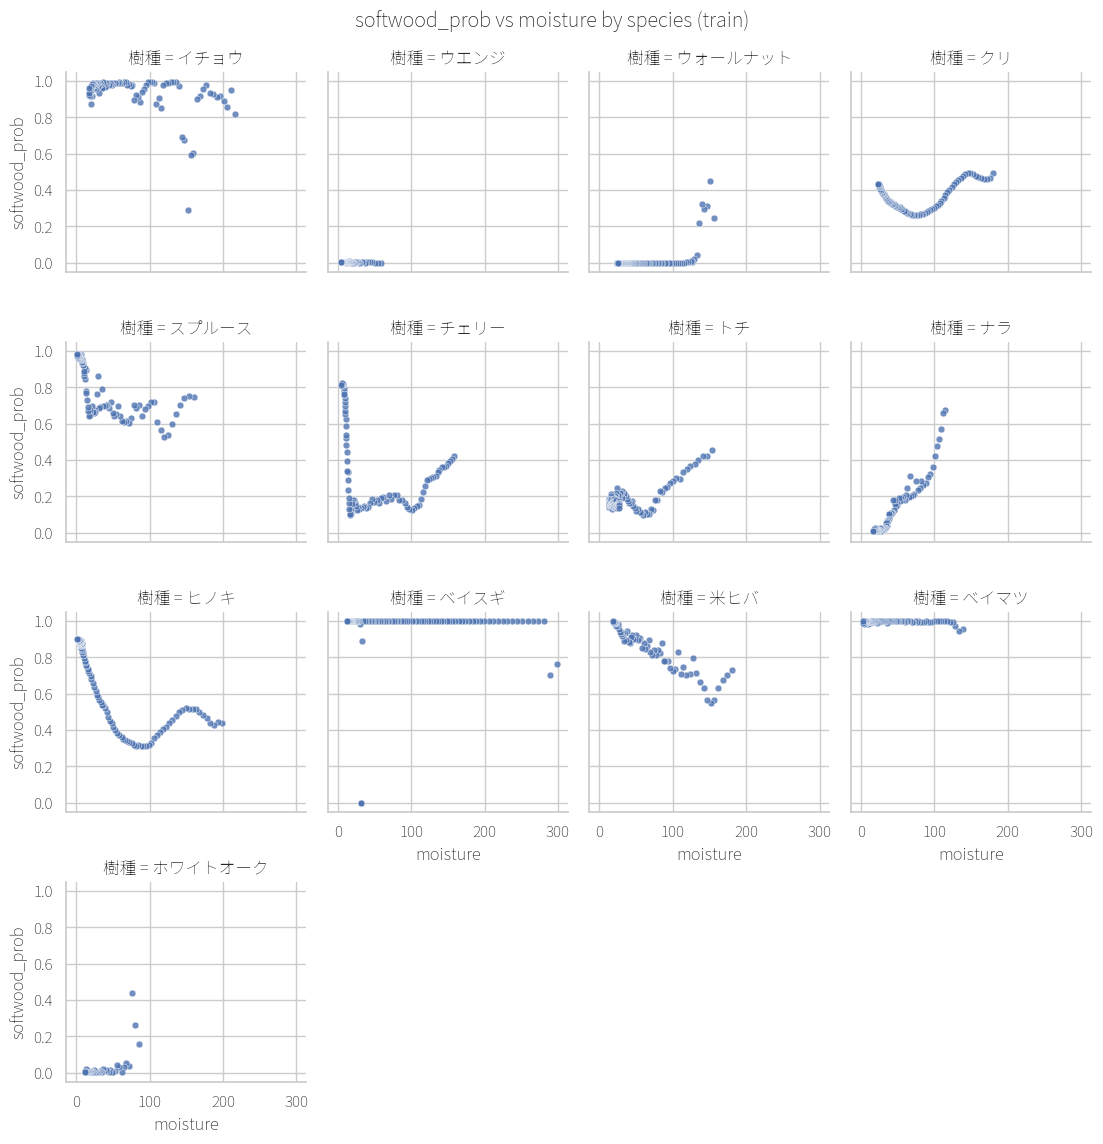

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_exp, x=TARGET_COL, y="softwood_prob", hue=SPECIES_COL, s=28, alpha=0.75)
plt.title("softwood_prob vs moisture by species (train)")
plt.xlabel("moisture")
plt.ylabel("softwood_prob")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
savefig("exp1_softwood_prob_vs_moisture_overlay_train.png")
plt.show()
plt.close("all")

g = sns.relplot(
    data=train_exp,
    x=TARGET_COL,
    y="softwood_prob",
    col=SPECIES_COL,
    col_wrap=4,
    kind="scatter",
    height=2.8,
    facet_kws={"sharex": True, "sharey": True},
    s=24,
    alpha=0.8,
)
g.set_axis_labels("moisture", "softwood_prob")
g.fig.suptitle("softwood_prob vs moisture by species (train)", y=1.02)
g.savefig(OUTPUT_DIR / "exp1_softwood_prob_vs_moisture_grid_train.png", dpi=150, bbox_inches="tight")
print("saved:", OUTPUT_DIR / "exp1_softwood_prob_vs_moisture_grid_train.png")
plt.show()
plt.close("all")

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp1_softwood_prob_by_species_index_train.png


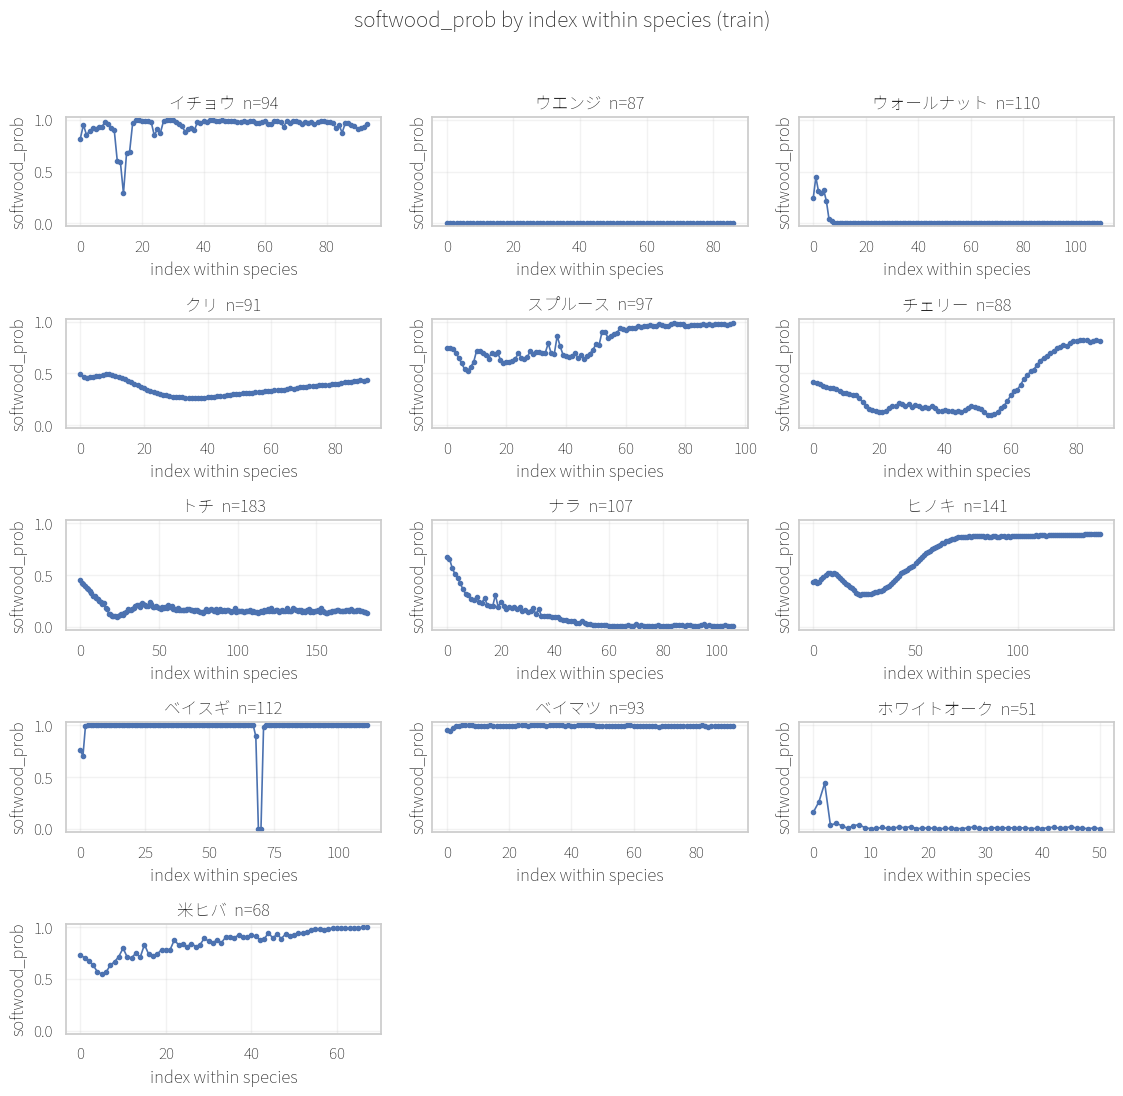

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp1_softwood_prob_by_species_index_test.png


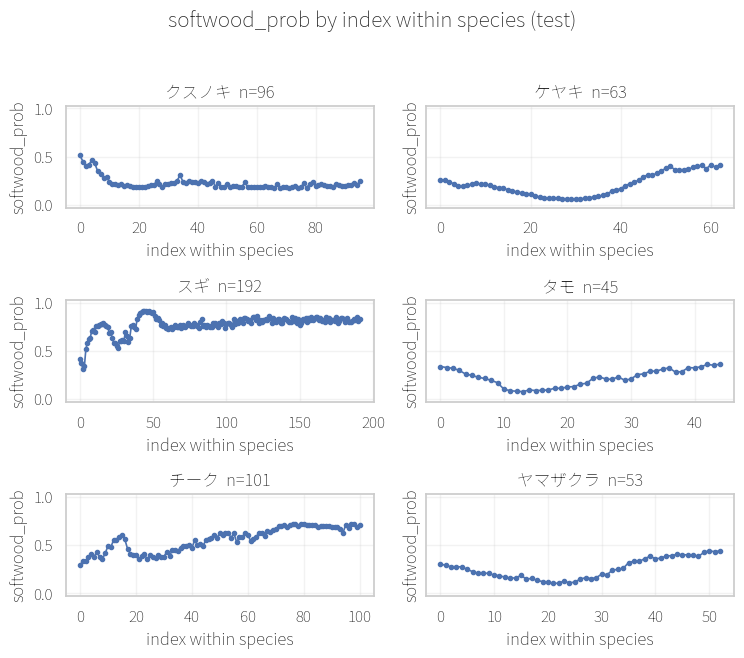

In [5]:
def plot_prob_by_species_index(df: pd.DataFrame, split_name: str, filename: str) -> None:
    plt.close("all")
    keep_cols = [SPECIES_COL, "softwood_prob"]
    if SAMPLE_COL in df.columns:
        keep_cols.append(SAMPLE_COL)
    work = df[keep_cols].sort_values([SPECIES_COL, SAMPLE_COL] if SAMPLE_COL in df.columns else [SPECIES_COL]).copy()
    work["species_index"] = work.groupby(SPECIES_COL, dropna=False).cumcount()
    species_values = work[SPECIES_COL].dropna().astype(str).unique().tolist()
    ncols = 3 if len(species_values) > 6 else 2
    nrows = math.ceil(len(species_values) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 2.2 * nrows), sharey=True)
    axes = np.asarray(axes).reshape(-1)
    for ax, species in zip(axes, species_values):
        g = work[work[SPECIES_COL].astype(str) == species]
        ax.plot(g["species_index"], g["softwood_prob"], marker="o", ms=3, lw=1.2)
        ax.set_title(f"{species}  n={len(g)}")
        ax.set_xlabel("index within species")
        ax.set_ylabel("softwood_prob")
        ax.set_ylim(-0.03, 1.03)
        ax.grid(True, alpha=0.25)
    for ax in axes[len(species_values):]:
        ax.axis("off")
    fig.suptitle(f"softwood_prob by index within species ({split_name})", y=0.995, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    savefig(filename)
    plt.show()


plot_prob_by_species_index(train_exp, "train", "exp1_softwood_prob_by_species_index_train.png")
plot_prob_by_species_index(test_exp, "test", "exp1_softwood_prob_by_species_index_test.png")

## Experiment 2: Correlation With Existing Features

In [6]:
def build_spectral_summary_features(raw_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    spectral_cols = detect_spectral_columns(raw_df)
    if not spectral_cols:
        csv_name = config.train_csv if split_name == "train" else config.test_csv
        csv_path = PROJECT_ROOT / "data" / csv_name
        header = pd.read_csv(csv_path, encoding="cp932", nrows=0, engine="python").columns
        spectral_cols = []
        for col in header:
            try:
                float(col)
                spectral_cols.append(col)
            except ValueError:
                continue
        spectral_dtypes = {col: "float32" for col in spectral_cols}
        spectral_df = pd.read_csv(csv_path, encoding="cp932", usecols=spectral_cols, dtype=spectral_dtypes, engine="python")
    else:
        spectral_df = raw_df[spectral_cols]

    wavenumbers = np.asarray([float(c) for c in spectral_cols], dtype=float)
    wavelengths = 1e7 / wavenumbers
    order = np.argsort(wavelengths)
    sorted_cols = [spectral_cols[i] for i in order]
    wavelengths = wavelengths[order]
    raw = spectral_df[sorted_cols].to_numpy(dtype=np.float32)

    view_names = list(VIEW_NAMES)
    bands = [(1400, 1500), (1850, 1950), (2100, 2300)]
    broad_bands = [(1000, 1300), (1300, 1600), (1600, 1800), (1800, 2000), (2000, 2300), (2300, 2500)]

    parts = []
    snv_x = snv(raw).astype(np.float32)
    for view_name in view_names:
        if view_name == "raw":
            view = raw
        elif view_name == "snv":
            view = snv_x
        elif view_name == "raw_sg1":
            view = savitzky_golay_derivative(raw, 1, config.sg_window_length, config.sg_polyorder)
        elif view_name == "snv_sg1":
            view = savitzky_golay_derivative(snv_x, 1, config.sg_window_length, config.sg_polyorder)
        elif view_name == "raw_sg2":
            view = savitzky_golay_derivative(raw, 2, config.sg_window_length, config.sg_polyorder)
        elif view_name == "snv_sg2":
            view = savitzky_golay_derivative(snv_x, 2, config.sg_window_length, config.sg_polyorder)
        view = np.asarray(view, dtype=np.float32)
        parts.append(band_means(view, wavelengths, bands + broad_bands).add_prefix(f"{view_name}_"))
        parts.append(spectral_slopes(view, wavelengths, bands).add_prefix(f"{view_name}_"))
        parts.append(pd.DataFrame({f"{view_name}_energy": (view ** 2).mean(axis=1)}))

    features = pd.concat(parts, axis=1)
    features["water_1450_mean_all_views"] = features[[c for c in features.columns if "1400_1500" in c]].mean(axis=1)
    features["water_1900_mean_all_views"] = features[[c for c in features.columns if "1850_1950" in c]].mean(axis=1)
    features["structure_2100_2300_mean_all_views"] = features[[c for c in features.columns if "2100_2300" in c]].mean(axis=1)
    features["scatter_proxy_raw_std"] = np.nanstd(raw, axis=1)
    features["scatter_proxy_raw_range"] = np.nanmax(raw, axis=1) - np.nanmin(raw, axis=1)
    features["scatter_proxy_snv_std"] = np.nanstd(snv_x, axis=1)
    return features


train_feature_summary = build_spectral_summary_features(train_base, "train")
test_feature_summary = build_spectral_summary_features(test_base, "test")
train_corr_df = pd.concat([train_exp[[SAMPLE_COL, SPECIES_COL, TARGET_COL, "softwood_prob"]].reset_index(drop=True), train_feature_summary.reset_index(drop=True)], axis=1)
test_corr_df = pd.concat([test_exp[[SAMPLE_COL, SPECIES_COL, "softwood_prob"]].reset_index(drop=True), test_feature_summary.reset_index(drop=True)], axis=1)
print("train correlation feature table:", train_corr_df.shape)
print("test correlation feature table:", test_corr_df.shape)

train correlation feature table: (1322, 88)
test correlation feature table: (550, 87)


,group,feature,n,pearson,spearman,abs_pearson,abs_spearman
0,all,snv_sg1_mean_1600_1800,1322,-0.735277,-0.679155,0.735277,0.679155
1,all,raw_sg1_mean_1600_1800,1322,-0.602336,-0.647274,0.602336,0.647274
2,all,snv_sg2_mean_1850_1950,1322,0.502957,0.528835,0.502957,0.528835
3,all,snv_sg1_slope_1850_1950,1322,0.498518,0.525850,0.498518,0.525850
4,all,structure_2100_2300_mean_all_views,1322,-0.404952,-0.422737,0.404952,0.422737
5,all,snv_sg1_mean_1000_1300,1322,0.299357,0.413758,0.299357,0.413758
6,all,raw_sg2_mean_1850_1950,1322,0.364601,0.409753,0.364601,0.409753
7,all,raw_sg1_slope_1850_1950,1322,0.380834,0.393799,0.380834,0.393799
8,all,raw_sg2_mean_1400_1500,1322,0.215750,0.370635,0.215750,0.370635
9,all,raw_sg1_slope_1400_1500,1322,0.216601,0.369322,0.216601,0.369322


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp2_top30_softwood_correlations_train.png


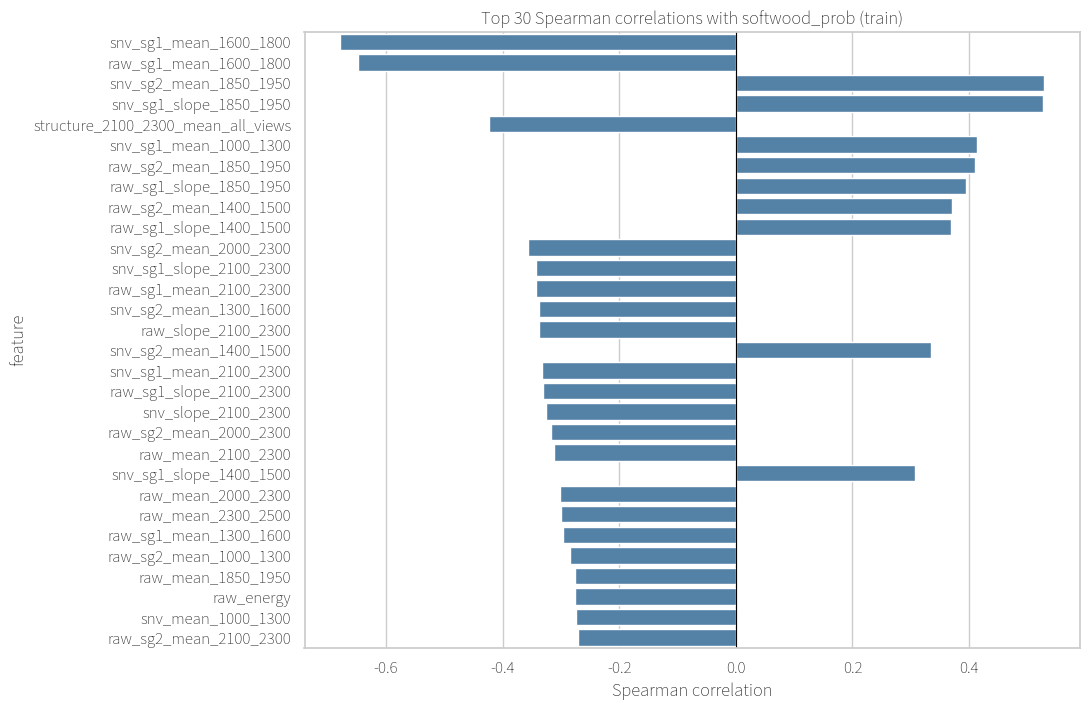

In [7]:
def softwood_correlations(df: pd.DataFrame, group_col: str | None = None) -> pd.DataFrame:
    feature_cols = [c for c in numeric_feature_columns(df, exclude_probability=True) if c != "softwood_prob"]
    rows = []
    groups = [("all", df)] if group_col is None else list(df.groupby(group_col, dropna=False))
    for group_name, g in groups:
        if len(g) < 4:
            continue
        y = pd.to_numeric(g["softwood_prob"], errors="coerce")
        for col in feature_cols:
            x = pd.to_numeric(g[col], errors="coerce")
            valid = x.notna() & y.notna()
            if valid.sum() < 4 or x[valid].nunique() < 2:
                continue
            rows.append({
                "group": group_name,
                "feature": col,
                "n": int(valid.sum()),
                "pearson": float(x[valid].corr(y[valid], method="pearson")),
                "spearman": float(x[valid].corr(y[valid], method="spearman")),
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["abs_pearson"] = out["pearson"].abs()
        out["abs_spearman"] = out["spearman"].abs()
        out = out.sort_values(["abs_spearman", "abs_pearson"], ascending=False).reset_index(drop=True)
    return out


exp2_corr_all = softwood_correlations(train_corr_df)
exp2_corr_species = softwood_correlations(train_corr_df, SPECIES_COL)
exp2_corr_all.to_csv(OUTPUT_DIR / "exp2_softwood_feature_correlations_train.csv", index=False, encoding="utf-8-sig")
exp2_corr_species.to_csv(OUTPUT_DIR / "exp2_softwood_feature_correlations_by_species_train.csv", index=False, encoding="utf-8-sig")

exp2_top30 = exp2_corr_all.head(30)
display(exp2_top30)
plt.figure(figsize=(10, 8))
sns.barplot(data=exp2_top30, y="feature", x="spearman", color="steelblue")
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 30 Spearman correlations with softwood_prob (train)")
plt.xlabel("Spearman correlation")
plt.ylabel("feature")
savefig("exp2_top30_softwood_correlations_train.png")
plt.show()

## Experiment 3: Predict Moisture From Woodtype Probability Only

In [8]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

PROB_FEATURES = ["softwood_prob", "hardwood_prob", "entropy_woodtype", "uncertainty_woodtype"]
prob_models = {
    "LinearRegression": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "SVR_RBF": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", SVR(kernel="rbf", C=10.0, gamma="scale"))]),
    "RandomForest": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=100, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))]),
}


def oof_regression(df: pd.DataFrame, feature_cols: list[str], models: dict[str, object], group_col: str = SPECIES_COL) -> tuple[pd.DataFrame, pd.DataFrame]:
    X, y = clean_xy(df[feature_cols], df[TARGET_COL])
    meta = df.loc[pd.Series(df[TARGET_COL]).notna().to_numpy(), [SAMPLE_COL, SPECIES_COL, TARGET_COL]].reset_index(drop=True).copy()
    groups = meta[group_col]
    cv = make_group_kfold(groups)
    pred_frame = meta.copy()
    summary_rows = []
    for model_name, estimator in models.items():
        oof = np.full(len(meta), np.nan, dtype=float)
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
            model = clone(estimator)
            model.fit(X.iloc[tr_idx], y[tr_idx])
            oof[va_idx] = model.predict(X.iloc[va_idx])
        pred_col = f"pred_{model_name}"
        pred_frame[pred_col] = oof
        summary_rows.append({"experiment": "exp3_prob_only", "model": model_name, "features": "+".join(feature_cols), "oof_rmse": safe_rmse(y, oof)})
    summary = pd.DataFrame(summary_rows).sort_values("oof_rmse").reset_index(drop=True)
    return pred_frame, summary


exp3_oof, exp3_summary = oof_regression(train_exp, PROB_FEATURES, prob_models)
exp3_summary.to_csv(OUTPUT_DIR / "exp3_probability_only_summary.csv", index=False, encoding="utf-8-sig")
display(exp3_summary)

,experiment,model,features,oof_rmse
0,exp3_prob_only,Ridge,softwood_prob+hardwood_prob+entropy_woodtype+u...,47.089523
1,exp3_prob_only,LinearRegression,softwood_prob+hardwood_prob+entropy_woodtype+u...,47.099703
2,exp3_prob_only,SVR_RBF,softwood_prob+hardwood_prob+entropy_woodtype+u...,51.894989
3,exp3_prob_only,RandomForest,softwood_prob+hardwood_prob+entropy_woodtype+u...,54.319629


,species,n,rmse
0,ベイスギ,112,91.771940
1,イチョウ,94,68.009544
2,チェリー,88,52.797766
3,ヒノキ,141,48.707414
4,クリ,91,44.152392
5,スプルース,97,42.242328
6,米ヒバ,68,41.960740
7,ベイマツ,93,38.459006
8,ウォールナット,110,37.089704
9,ウエンジ,87,31.370773


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp3_oof_actual_vs_pred.png


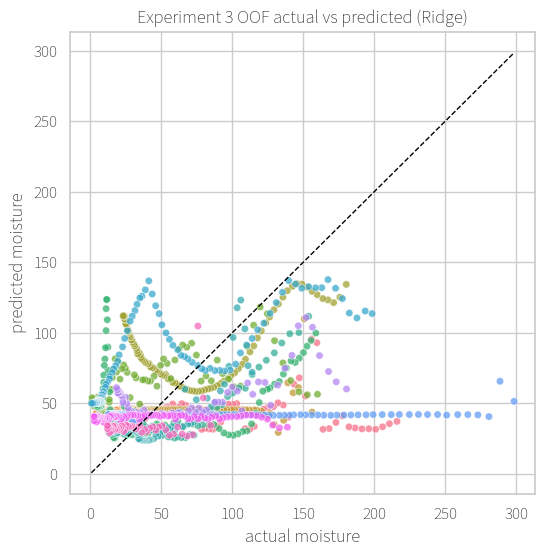

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp3_species_index_actual_vs_pred.png


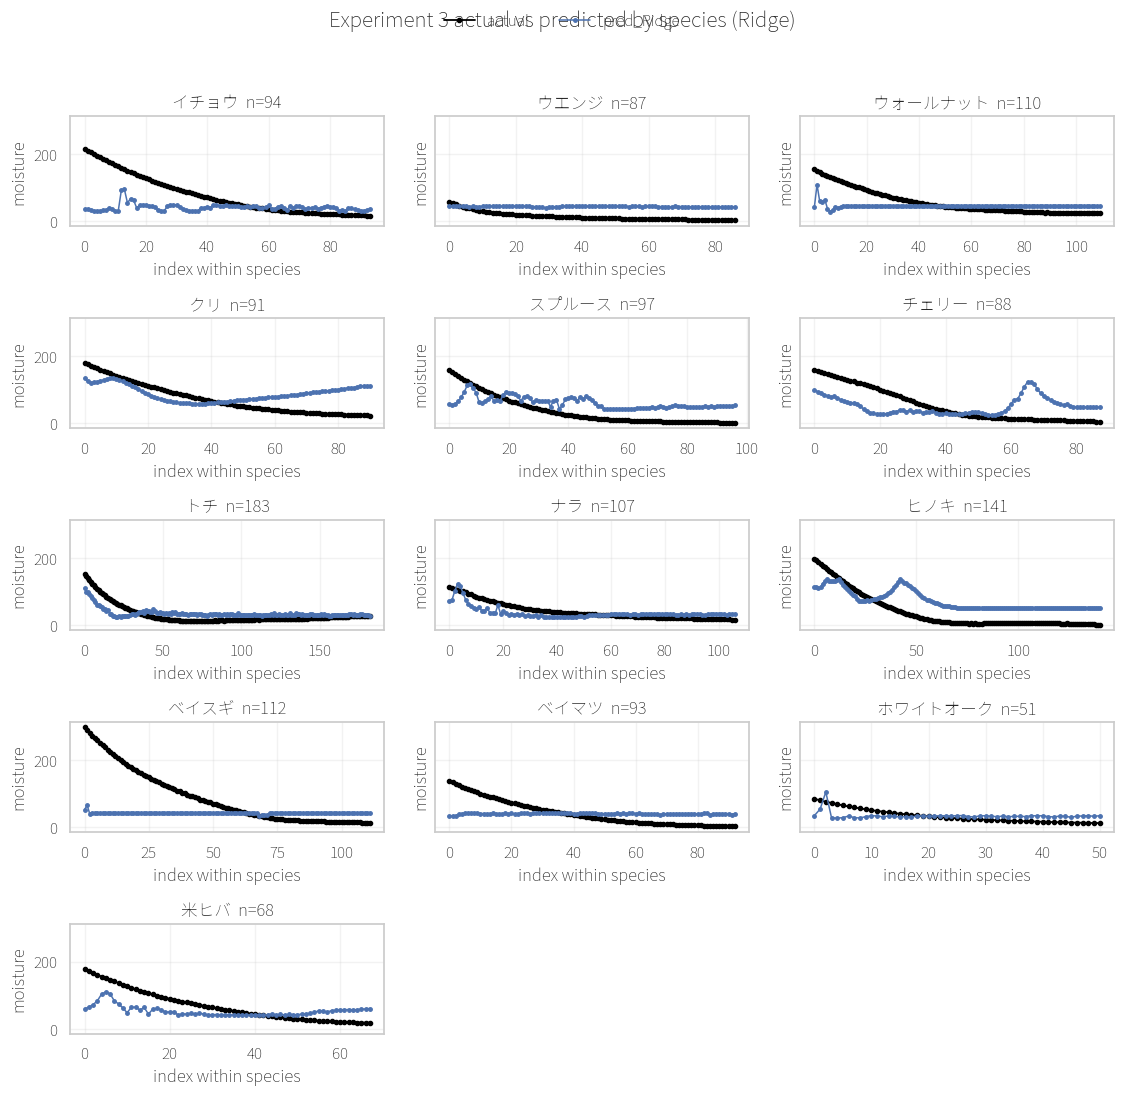

In [9]:
best_exp3_model = exp3_summary.iloc[0]["model"]
best_exp3_pred_col = f"pred_{best_exp3_model}"
exp3_species_rmse = species_rmse_table(exp3_oof, best_exp3_pred_col)
exp3_species_rmse.to_csv(OUTPUT_DIR / "exp3_probability_only_species_rmse.csv", index=False, encoding="utf-8-sig")
display(exp3_species_rmse)
plot_actual_pred(exp3_oof, best_exp3_pred_col, f"Experiment 3 OOF actual vs predicted ({best_exp3_model})", "exp3_oof_actual_vs_pred.png")
plot_species_index_predictions(exp3_oof, [best_exp3_pred_col], f"Experiment 3 actual vs predicted by species ({best_exp3_model})", "exp3_species_index_actual_vs_pred.png")

## Experiment 4: Mixture of Experts

In [10]:
def existing_moisture_feature_candidates(df: pd.DataFrame) -> list[str]:
    keywords = ["1450", "1900", "2100", "2200", "2300", "water", "scatter", "raw_", "snv", "sg1", "sg2", "mean_", "slope_", "energy"]
    numeric_cols = numeric_feature_columns(df, exclude_probability=True)
    return [c for c in numeric_cols if any(k in str(c).lower() for k in keywords)]


moe_train_full = pd.concat([train_exp.reset_index(drop=True), train_feature_summary.reset_index(drop=True)], axis=1)
moe_test_full = pd.concat([test_exp.reset_index(drop=True), test_feature_summary.reset_index(drop=True)], axis=1)
feature_cols = existing_moisture_feature_candidates(moe_train_full)
if not feature_cols:
    feature_cols = numeric_feature_columns(moe_train_full, exclude_probability=True)
common_feature_cols = [c for c in feature_cols if c in moe_train_full.columns and c in moe_test_full.columns]
print("MoE feature count:", len(common_feature_cols))
display(pd.DataFrame({"feature": common_feature_cols}).head(30))

MOE_BASE_ESTIMATOR = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0)),
])

MoE feature count: 84


,feature
0,raw_mean_1400_1500
1,raw_mean_1850_1950
2,raw_mean_2100_2300
3,raw_mean_1000_1300
4,raw_mean_1300_1600
5,raw_mean_1600_1800
6,raw_mean_1800_2000
7,raw_mean_2000_2300
8,raw_mean_2300_2500
9,raw_slope_1400_1500


In [11]:
def fit_predict_weighted(estimator, X_train, y_train, X_valid, sample_weight=None):
    model = clone(estimator)
    if sample_weight is None:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, model__sample_weight=sample_weight)
    return model.predict(X_valid), model


def oof_mixture_of_experts(df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    needed = [*feature_cols, "softwood_prob", "hardwood_prob", TARGET_COL, SPECIES_COL, SAMPLE_COL]
    work = df[needed].replace([np.inf, -np.inf], np.nan).copy()
    work = work.loc[work[TARGET_COL].notna()].reset_index(drop=True)
    X = work[feature_cols]
    y = work[TARGET_COL].to_numpy(dtype=float)
    groups = work[SPECIES_COL]
    cv = make_group_kfold(groups)
    pred_cols = ["pred_global_model", "pred_soft_only_model", "pred_hard_only_model", "pred_mixture_model"]
    for col in pred_cols:
        work[col] = np.nan
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr = y[tr_idx]
        p_soft_tr = work.loc[tr_idx, "softwood_prob"].fillna(0.5).clip(1e-4, 1.0).to_numpy(dtype=float)
        p_hard_tr = work.loc[tr_idx, "hardwood_prob"].fillna(0.5).clip(1e-4, 1.0).to_numpy(dtype=float)
        p_soft_va = work.loc[va_idx, "softwood_prob"].fillna(0.5).clip(0.0, 1.0).to_numpy(dtype=float)
        p_hard_va = work.loc[va_idx, "hardwood_prob"].fillna(0.5).clip(0.0, 1.0).to_numpy(dtype=float)
        total_va = np.where((p_soft_va + p_hard_va) == 0, 1.0, p_soft_va + p_hard_va)
        p_soft_va = p_soft_va / total_va
        p_hard_va = p_hard_va / total_va
        pred_global, _ = fit_predict_weighted(MOE_BASE_ESTIMATOR, X_tr, y_tr, X_va)
        pred_soft, _ = fit_predict_weighted(MOE_BASE_ESTIMATOR, X_tr, y_tr, X_va, sample_weight=p_soft_tr)
        pred_hard, _ = fit_predict_weighted(MOE_BASE_ESTIMATOR, X_tr, y_tr, X_va, sample_weight=p_hard_tr)
        work.loc[va_idx, "pred_global_model"] = pred_global
        work.loc[va_idx, "pred_soft_only_model"] = pred_soft
        work.loc[va_idx, "pred_hard_only_model"] = pred_hard
        work.loc[va_idx, "pred_mixture_model"] = p_soft_va * pred_soft + p_hard_va * pred_hard
    summary = pd.DataFrame([
        {"experiment": "exp4_mixture_of_experts", "model": col.replace("pred_", ""), "feature_count": len(feature_cols), "oof_rmse": safe_rmse(work[TARGET_COL], work[col])}
        for col in pred_cols
    ]).sort_values("oof_rmse").reset_index(drop=True)
    species_rmse = pd.concat([species_rmse_table(work, col).assign(model=col.replace("pred_", "")) for col in pred_cols], ignore_index=True)
    bin_rmse = pd.concat([moisture_bin_rmse_table(work, col).assign(model=col.replace("pred_", "")) for col in pred_cols], ignore_index=True)
    return work, summary, species_rmse, bin_rmse


exp4_oof, exp4_summary, exp4_species_rmse, exp4_bin_rmse = oof_mixture_of_experts(moe_train_full, common_feature_cols)
exp4_oof.to_csv(OUTPUT_DIR / "exp4_mixture_oof_predictions.csv", index=False, encoding="utf-8-sig")
exp4_summary.to_csv(OUTPUT_DIR / "exp4_mixture_summary.csv", index=False, encoding="utf-8-sig")
exp4_species_rmse.to_csv(OUTPUT_DIR / "exp4_mixture_species_rmse.csv", index=False, encoding="utf-8-sig")
exp4_bin_rmse.to_csv(OUTPUT_DIR / "exp4_mixture_moisture_bin_rmse.csv", index=False, encoding="utf-8-sig")
display(exp4_summary)
display(exp4_species_rmse.head(30))
display(exp4_bin_rmse)

,experiment,model,feature_count,oof_rmse
0,exp4_mixture_of_experts,hard_only_model,84,141.178013
1,exp4_mixture_of_experts,mixture_model,84,202.794265
2,exp4_mixture_of_experts,soft_only_model,84,270.423902
3,exp4_mixture_of_experts,global_model,84,291.879349


,species,n,rmse,model
0,ベイスギ,112,995.482231,global_model
1,ウエンジ,87,75.479011,global_model
2,ウォールナット,110,70.251727,global_model
3,イチョウ,94,38.583553,global_model
4,ヒノキ,141,28.545783,global_model
5,チェリー,88,28.119606,global_model
6,トチ,183,24.442908,global_model
7,スプルース,97,23.542280,global_model
8,ホワイトオーク,51,22.465729,global_model
9,クリ,91,21.819427,global_model


,mc_bin,n,rmse,model
0,"(0.839, 11.764]",221,42.706969,global_model
1,"(11.764, 19.679]",222,204.349222,global_model
2,"(19.679, 29.053]",218,314.474867,global_model
3,"(29.053, 50.595]",220,605.319919,global_model
4,"(50.595, 97.287]",220,31.021705,global_model
5,"(97.287, 298.582]",221,50.830245,global_model
6,"(0.839, 11.764]",221,23.906632,soft_only_model
7,"(11.764, 19.679]",222,227.650779,soft_only_model
8,"(19.679, 29.053]",218,297.424036,soft_only_model
9,"(29.053, 50.595]",220,543.508927,soft_only_model


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp4_oof_actual_vs_pred_best.png


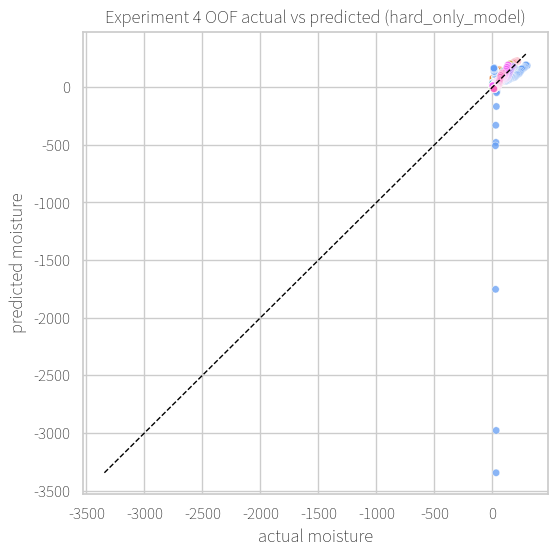

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp4_species_index_actual_vs_pred_global_vs_mixture.png


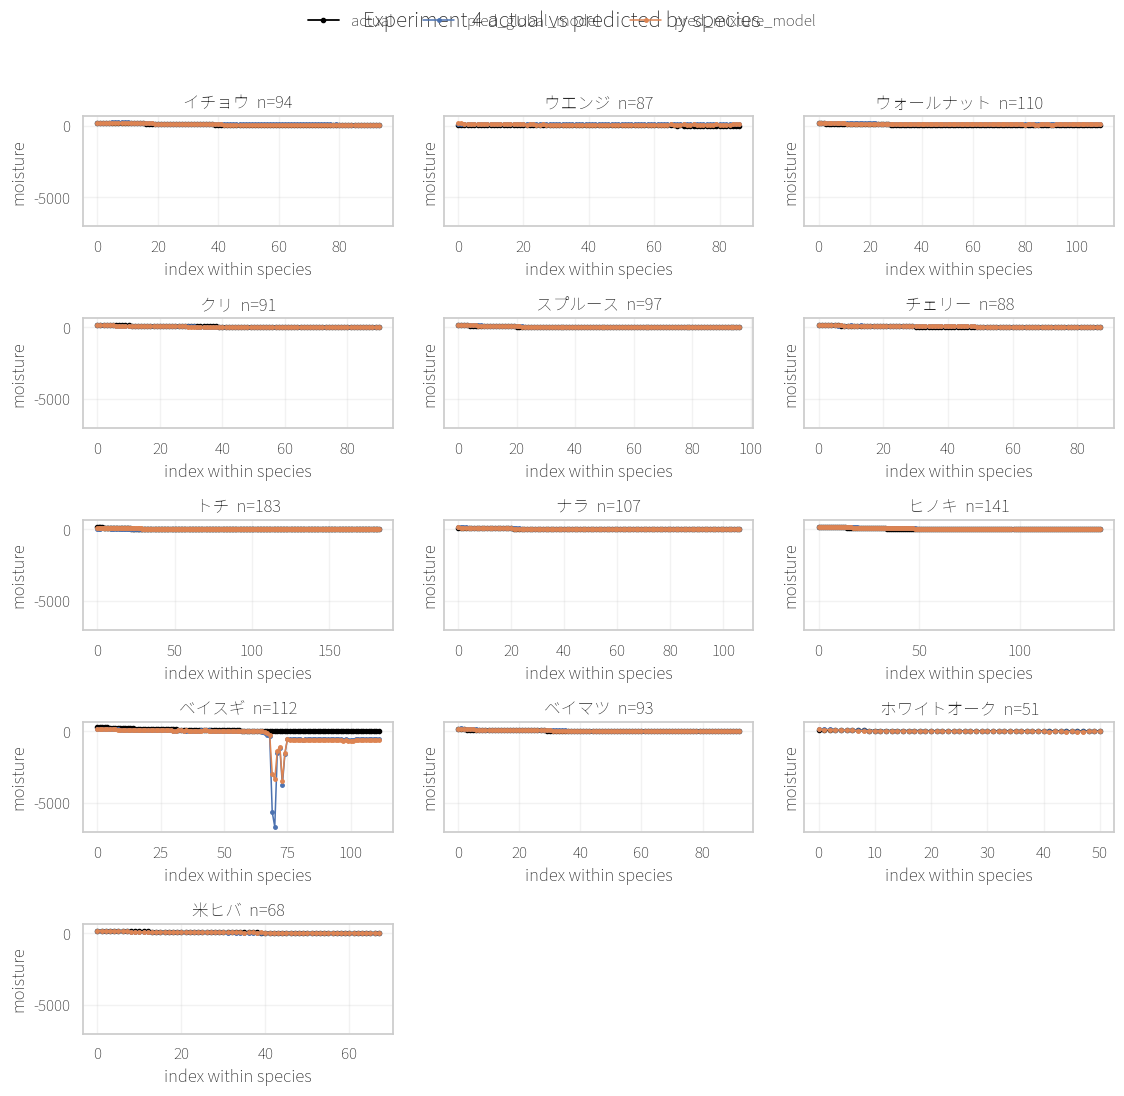

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp4_oof_rmse_comparison.png


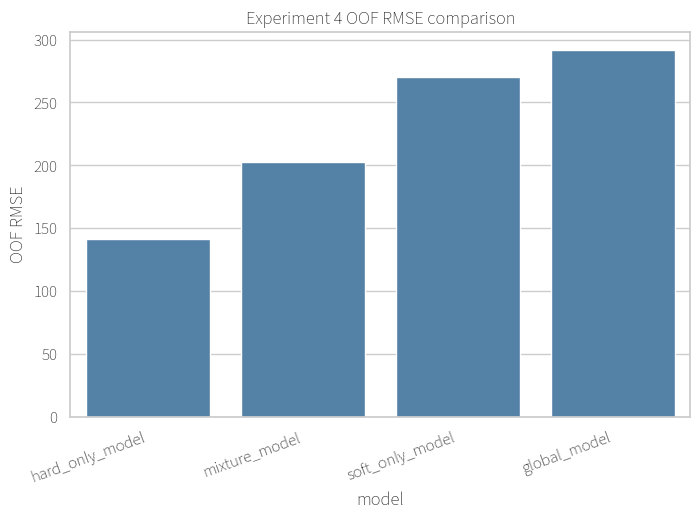

In [12]:
best_exp4_model = exp4_summary.iloc[0]["model"]
best_exp4_pred_col = f"pred_{best_exp4_model}"
plot_actual_pred(exp4_oof, best_exp4_pred_col, f"Experiment 4 OOF actual vs predicted ({best_exp4_model})", "exp4_oof_actual_vs_pred_best.png")
plot_species_index_predictions(exp4_oof, ["pred_global_model", "pred_mixture_model"], "Experiment 4 actual vs predicted by species", "exp4_species_index_actual_vs_pred_global_vs_mixture.png")

plt.figure(figsize=(8, 5))
sns.barplot(data=exp4_summary, x="model", y="oof_rmse", color="steelblue")
plt.title("Experiment 4 OOF RMSE comparison")
plt.xticks(rotation=20, ha="right")
plt.ylabel("OOF RMSE")
savefig("exp4_oof_rmse_comparison.png")
plt.show()

In [13]:
def fit_exp4_full_and_predict_test(train_df_full: pd.DataFrame, test_df_full: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    X_train = train_df_full[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train = train_df_full[TARGET_COL].to_numpy(dtype=float)
    X_test = test_df_full[feature_cols].replace([np.inf, -np.inf], np.nan)
    p_soft_train = train_df_full["softwood_prob"].fillna(0.5).clip(1e-4, 1.0).to_numpy(dtype=float)
    p_hard_train = train_df_full["hardwood_prob"].fillna(0.5).clip(1e-4, 1.0).to_numpy(dtype=float)
    p_soft_test = test_df_full["softwood_prob"].fillna(0.5).clip(0.0, 1.0).to_numpy(dtype=float)
    p_hard_test = test_df_full["hardwood_prob"].fillna(0.5).clip(0.0, 1.0).to_numpy(dtype=float)
    total = np.where((p_soft_test + p_hard_test) == 0, 1.0, p_soft_test + p_hard_test)
    p_soft_test = p_soft_test / total
    p_hard_test = p_hard_test / total
    pred_global, _ = fit_predict_weighted(MOE_BASE_ESTIMATOR, X_train, y_train, X_test)
    pred_soft, _ = fit_predict_weighted(MOE_BASE_ESTIMATOR, X_train, y_train, X_test, sample_weight=p_soft_train)
    pred_hard, _ = fit_predict_weighted(MOE_BASE_ESTIMATOR, X_train, y_train, X_test, sample_weight=p_hard_train)
    out_cols = [c for c in [SAMPLE_COL, "species number", SPECIES_COL, "softwood_prob", "hardwood_prob"] if c in test_df_full.columns]
    out = test_df_full[out_cols].copy()
    out["pred_global_model"] = pred_global
    out["pred_soft_only_model"] = pred_soft
    out["pred_hard_only_model"] = pred_hard
    out["pred_mixture_model"] = p_soft_test * pred_soft + p_hard_test * pred_hard
    return out


exp4_test_predictions = fit_exp4_full_and_predict_test(moe_train_full, moe_test_full, common_feature_cols)
exp4_test_predictions.to_csv(OUTPUT_DIR / "exp4_mixture_test_predictions.csv", index=False, encoding="utf-8-sig")
display(exp4_test_predictions.head())
print("saved:", OUTPUT_DIR / "exp4_mixture_test_predictions.csv")

,sample number,species number,樹種,softwood_prob,hardwood_prob,pred_global_model,pred_soft_only_model,pred_hard_only_model,pred_mixture_model
0,95,2,クスノキ,0.511000,0.489000,140.488570,134.093801,166.517563,149.949017
1,96,2,クスノキ,0.447765,0.552235,154.014362,150.394029,161.678681,156.625812
2,97,2,クスノキ,0.400190,0.599810,167.258871,165.123017,160.375951,162.275681
3,98,2,クスノキ,0.415448,0.584552,173.307692,170.681036,161.393102,165.251756
4,99,2,クスノキ,0.459612,0.540388,165.524665,165.263188,152.533349,158.384135


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\exp4_mixture_test_predictions.csv


## Summary And Short Notes

In [14]:
experiment_summary = pd.concat([exp3_summary, exp4_summary], ignore_index=True, sort=False)
experiment_summary.to_csv(OUTPUT_DIR / "cnn_woodtype_experiment_summary.csv", index=False, encoding="utf-8-sig")
display(experiment_summary)

best_exp3 = exp3_summary.iloc[0]
best_exp4 = exp4_summary.iloc[0]
print("考察:")
print("- 実験1では softwood_prob が樹種内・樹種間でどの程度連続的に変化するかを確認できます。急な段差があれば woodtype CNN の不確実性や樹種固有の分布差を疑うポイントです。")
print("- 実験2では softwood_prob と水特徴・構造特徴・scatter proxy の相関を確認できます。上位特徴が 1450/1900nm に寄る場合、水分吸収と woodtype 確率が絡んでいる可能性があります。")
print(f"- 実験3の最良モデルは {best_exp3['model']} で OOF RMSE={best_exp3['oof_rmse']:.4f} でした。probability 単独で説明できる含水率成分の上限を見る基準になります。")
print(f"- 実験4の最良モデルは {best_exp4['model']} で OOF RMSE={best_exp4['oof_rmse']:.4f} でした。global_model と mixture_model の差が、woodtype gating の有効性の目安です。")
print("saved:", OUTPUT_DIR / "cnn_woodtype_experiment_summary.csv")

,experiment,model,features,oof_rmse,feature_count
0,exp3_prob_only,Ridge,softwood_prob+hardwood_prob+entropy_woodtype+u...,47.089523,NaN
1,exp3_prob_only,LinearRegression,softwood_prob+hardwood_prob+entropy_woodtype+u...,47.099703,NaN
2,exp3_prob_only,SVR_RBF,softwood_prob+hardwood_prob+entropy_woodtype+u...,51.894989,NaN
3,exp3_prob_only,RandomForest,softwood_prob+hardwood_prob+entropy_woodtype+u...,54.319629,NaN
4,exp4_mixture_of_experts,hard_only_model,NaN,141.178013,84.0
5,exp4_mixture_of_experts,mixture_model,NaN,202.794265,84.0
6,exp4_mixture_of_experts,soft_only_model,NaN,270.423902,84.0
7,exp4_mixture_of_experts,global_model,NaN,291.879349,84.0


考察:
- 実験1では softwood_prob が樹種内・樹種間でどの程度連続的に変化するかを確認できます。急な段差があれば woodtype CNN の不確実性や樹種固有の分布差を疑うポイントです。
- 実験2では softwood_prob と水特徴・構造特徴・scatter proxy の相関を確認できます。上位特徴が 1450/1900nm に寄る場合、水分吸収と woodtype 確率が絡んでいる可能性があります。
- 実験3の最良モデルは Ridge で OOF RMSE=47.0895 でした。probability 単独で説明できる含水率成分の上限を見る基準になります。
- 実験4の最良モデルは hard_only_model で OOF RMSE=141.1780 でした。global_model と mixture_model の差が、woodtype gating の有効性の目安です。
saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\cnn_woodtype_experiments\cnn_woodtype_experiment_summary.csv
